# 🎨 04 — Visualise Results
### Gaza Building Damage Assessment Pipeline

Produces 8 publication-quality figures from the damage assessment outputs.

---
**Pipeline:**
1. ✅ `01_download_data.ipynb`
2. ✅ `02_prepare_scenes.ipynb`
3. ✅ `03_assess_damage.ipynb`
4. 🎨 `04_visualise.ipynb` ← *you are here*


## ⚙️ Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
import rasterio
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PREPARED_DIR = Path("data/prepared")
OUTPUT_DIR   = Path("outputs/damage")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DAMAGE_CLASSES = {0: "No Damage", 1: "Minor Damage", 2: "Major Damage", 3: "Destroyed"}
DAMAGE_COLORS  = ["#2ecc71", "#f39c12", "#e67e22", "#c0392b"]
DAMAGE_CMAP    = ListedColormap(DAMAGE_COLORS)

CLASS_NAMES = [
    "Annual Crop", "Forest", "Herbaceous Veg", "Highway",
    "Industrial", "Pasture", "Permanent Crop", "Residential",
    "River", "Sea / Lake",
]
CLASS_COLORS = [
    (0.78,0.52,0.25),(0.13,0.37,0.13),(0.42,0.68,0.35),(0.65,0.60,0.45),
    (0.45,0.45,0.55),(0.55,0.75,0.40),(0.25,0.55,0.15),(0.75,0.60,0.50),
    (0.20,0.50,0.80),(0.10,0.30,0.70),
]

def load_raster(path):
    with rasterio.open(path) as src:
        return src.read(), src.profile

def save(fig, name):
    path = OUTPUT_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"✅ Saved: {path}\n")

def mask_to_rgb(mask, colors):
    rgb = np.zeros((*mask.shape, 3))
    for i, c in enumerate(colors):
        rgb[mask == i] = c if isinstance(c[0], float) else [x/255 for x in c]
    return rgb

# Load all outputs
pre_rgb  = np.transpose(load_raster(PREPARED_DIR/"pre_rgb.tif")[0],  (1,2,0)).clip(0,1)
post_rgb = np.transpose(load_raster(PREPARED_DIR/"post_rgb.tif")[0], (1,2,0)).clip(0,1)
damage   = load_raster(OUTPUT_DIR/"damage_map.tif")[0][0]
pre_seg  = load_raster(OUTPUT_DIR/"pre_segmentation.tif")[0][0]
post_seg = load_raster(OUTPUT_DIR/"post_segmentation.tif")[0][0]
df       = pd.read_csv(OUTPUT_DIR/"damage_results.csv")

print("✅ All outputs loaded")
print(f"   Scene shape : {pre_rgb.shape}")
print(f"   Damage map  : {damage.shape}  unique={np.unique(damage).tolist()}")
print(f"   Results CSV : {len(df)} chips")


✅ All outputs loaded
   Scene shape : (1024, 1024, 3)
   Damage map  : (1024, 1024)  unique=[0, 1, 2]
   Results CSV : 441 chips


## 🛰️ Figure 1 — VHR Imagery: Before & After

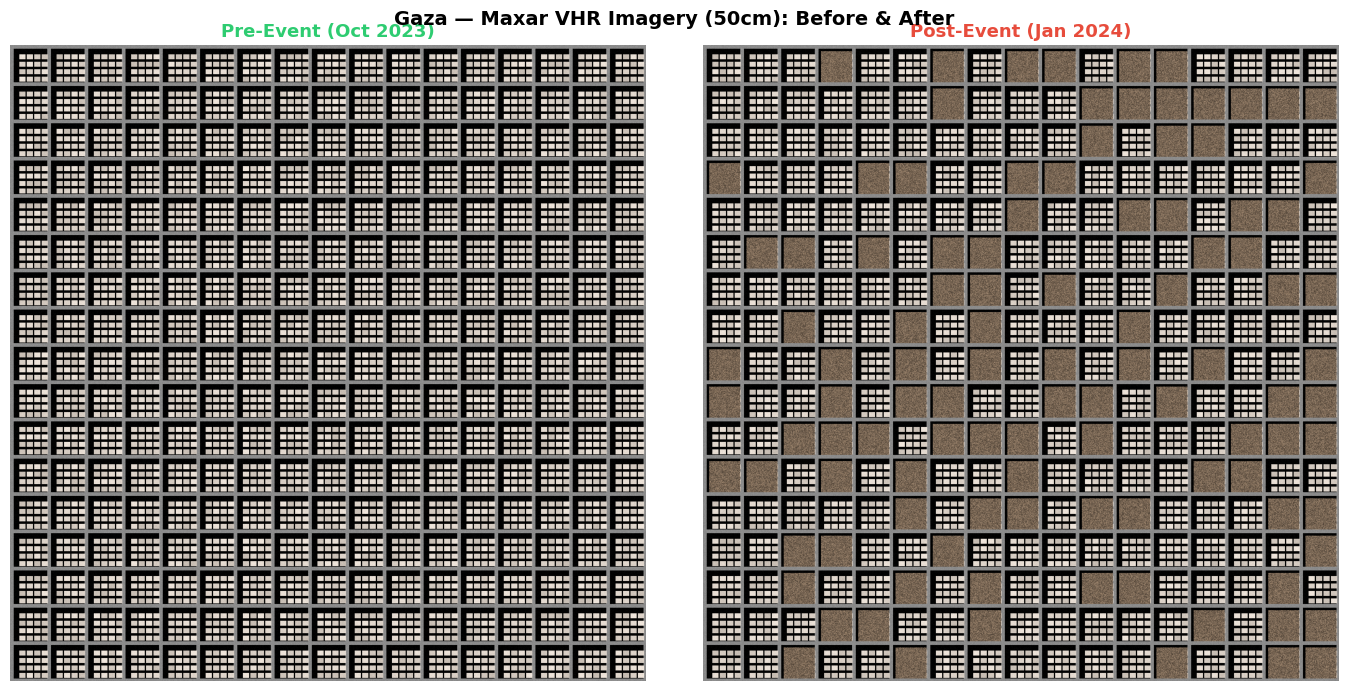

✅ Saved: outputs\damage\01_vhr_comparison.png



In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle("Gaza — Maxar VHR Imagery (50cm): Before & After", fontsize=14, fontweight="bold")
for ax, img, label, col in zip(
    axes,
    [pre_rgb, post_rgb],
    ["Pre-Event (Oct 2023)", "Post-Event (Jan 2024)"],
    ["#2ecc71", "#e74c3c"]
):
    ax.imshow(img)
    ax.set_title(label, fontsize=13, fontweight="bold", color=col)
    ax.axis("off")
    for s in ax.spines.values():
        s.set_edgecolor(col); s.set_linewidth(3); s.set_visible(True)
plt.tight_layout()
save(fig, "01_vhr_comparison.png")


## 🗺️ Figure 2 — DOFA Segmentation: Before & After

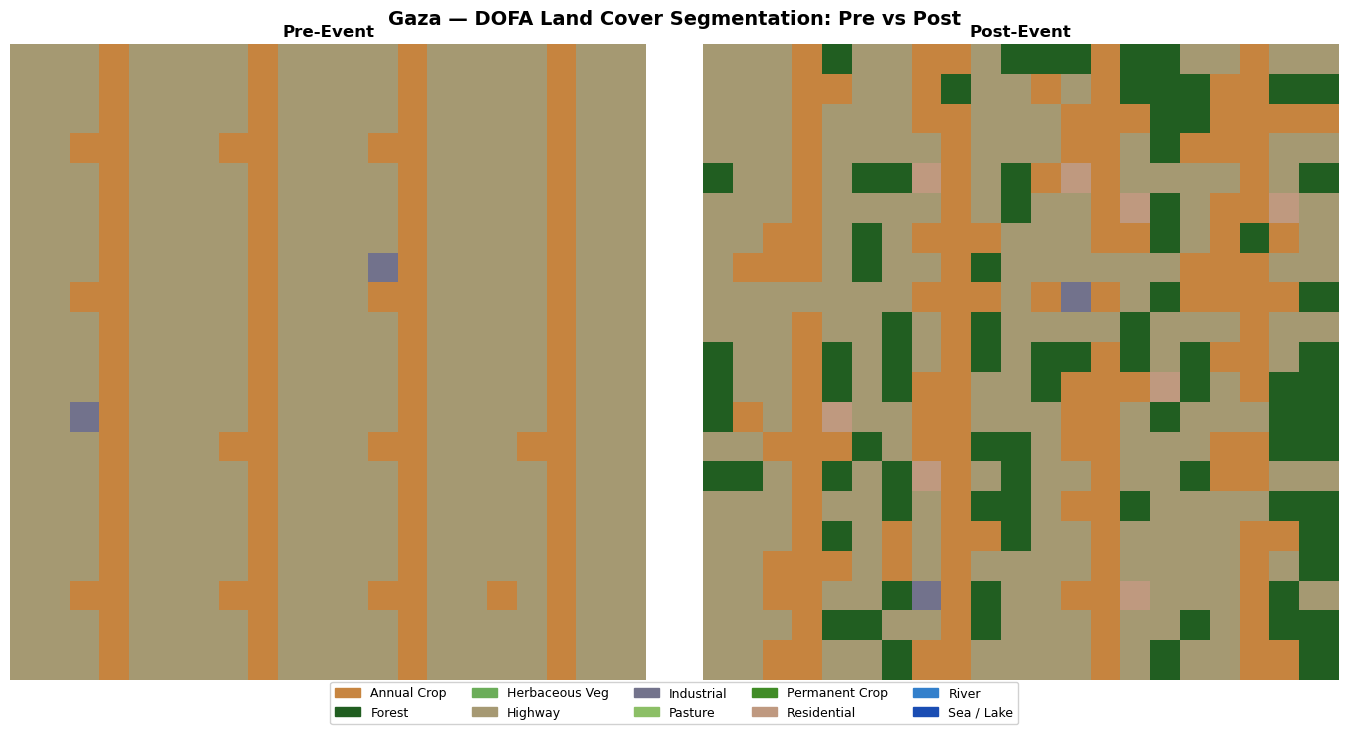

✅ Saved: outputs\damage\02_segmentation_comparison.png



In [3]:
seg_cmap = ListedColormap(CLASS_COLORS)
legend   = [mpatches.Patch(color=c, label=CLASS_NAMES[i]) for i, c in enumerate(CLASS_COLORS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle("Gaza — DOFA Land Cover Segmentation: Pre vs Post", fontsize=14, fontweight="bold")
for ax, seg, label in zip(axes, [pre_seg, post_seg], ["Pre-Event", "Post-Event"]):
    ax.imshow(mask_to_rgb(seg, CLASS_COLORS), interpolation="nearest")
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.axis("off")
fig.legend(handles=legend, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.05), fontsize=9, framealpha=0.9)
plt.tight_layout()
save(fig, "02_segmentation_comparison.png")


## 🔴 Figure 3 — Damage Map

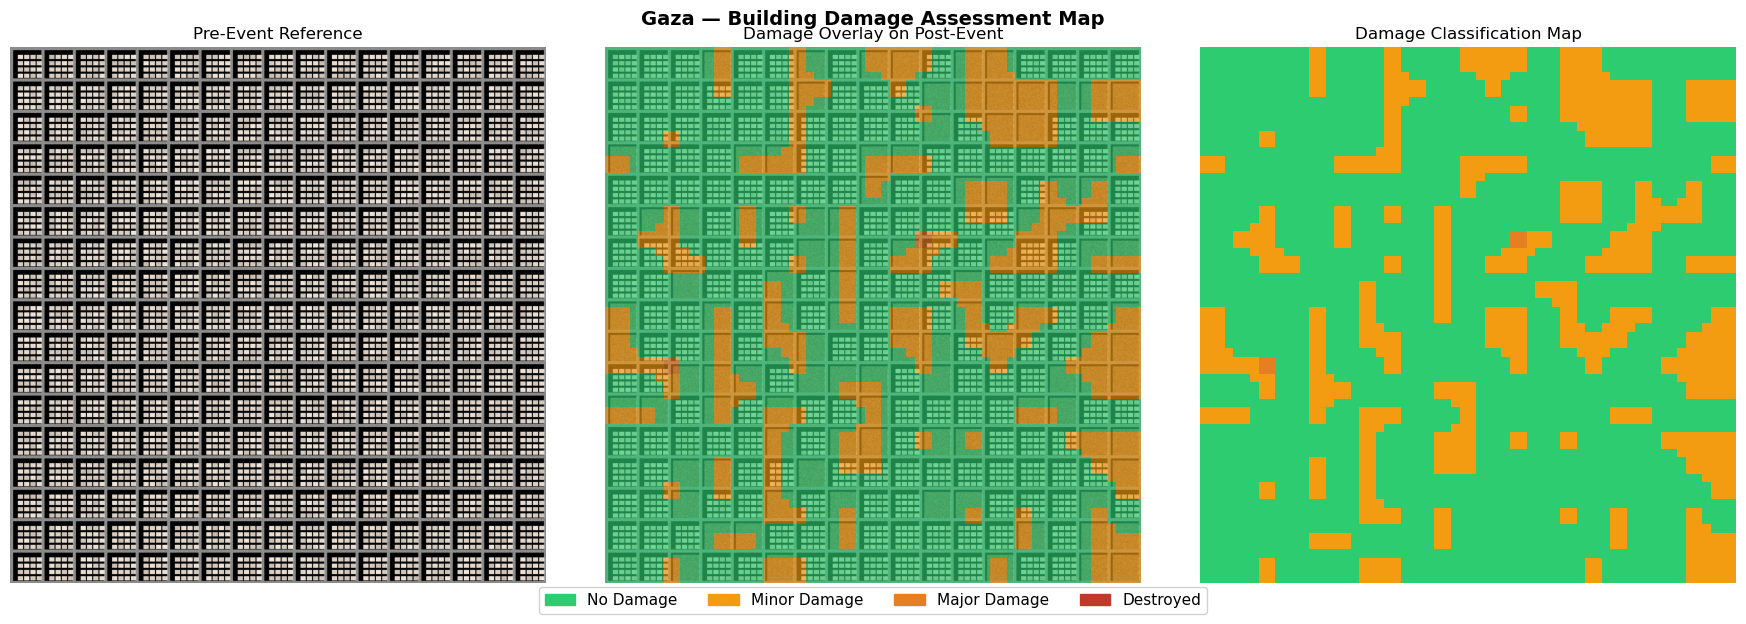

✅ Saved: outputs\damage\03_damage_map.png



In [4]:
damage_legend = [mpatches.Patch(color=DAMAGE_COLORS[i], label=DAMAGE_CLASSES[i])
                 for i in range(4)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Gaza — Building Damage Assessment Map", fontsize=14, fontweight="bold")

axes[0].imshow(pre_rgb)
axes[0].set_title("Pre-Event Reference"); axes[0].axis("off")

axes[1].imshow(post_rgb)
axes[1].imshow(mask_to_rgb(damage, [(int(c[1:3],16)/255, int(c[3:5],16)/255, int(c[5:7],16)/255)
                                     for c in DAMAGE_COLORS]),
               alpha=0.65, interpolation="nearest")
axes[1].set_title("Damage Overlay on Post-Event"); axes[1].axis("off")

axes[2].imshow(mask_to_rgb(damage, [(int(c[1:3],16)/255, int(c[3:5],16)/255, int(c[5:7],16)/255)
                                     for c in DAMAGE_COLORS]), interpolation="nearest")
axes[2].set_title("Damage Classification Map"); axes[2].axis("off")

fig.legend(handles=damage_legend, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.04), fontsize=11, framealpha=0.9)
plt.tight_layout()
save(fig, "03_damage_map.png")


## 📊 Figure 4 — Damage Distribution

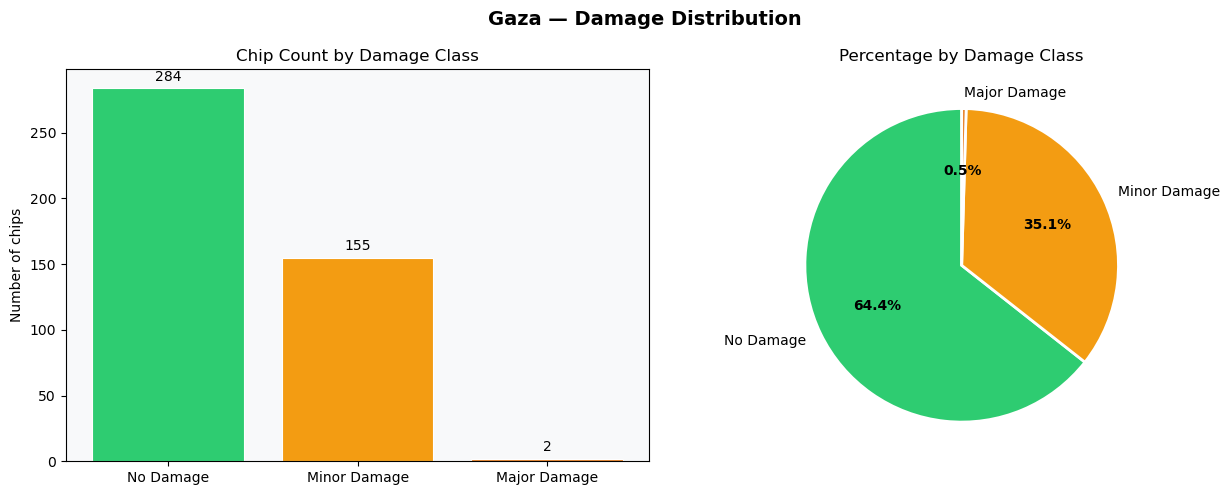

✅ Saved: outputs\damage\04_damage_distribution.png



In [5]:
counts = df["damage_class"].value_counts().sort_index()
labels = [DAMAGE_CLASSES[i] for i in counts.index]
colors = [DAMAGE_COLORS[i]  for i in counts.index]
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Gaza — Damage Distribution", fontsize=14, fontweight="bold")

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].bar_label(bars, fmt=lambda x: f"{int(x):,}", padding=3, fontsize=10)
axes[0].set_ylabel("Number of chips"); axes[0].set_facecolor("#f8f9fa")
axes[0].set_title("Chip Count by Damage Class")
fig.patch.set_facecolor("white")

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold")
axes[1].set_title("Percentage by Damage Class")

plt.tight_layout()
save(fig, "04_damage_distribution.png")


## 🔍 Figure 5 — Chip Examples by Damage Class

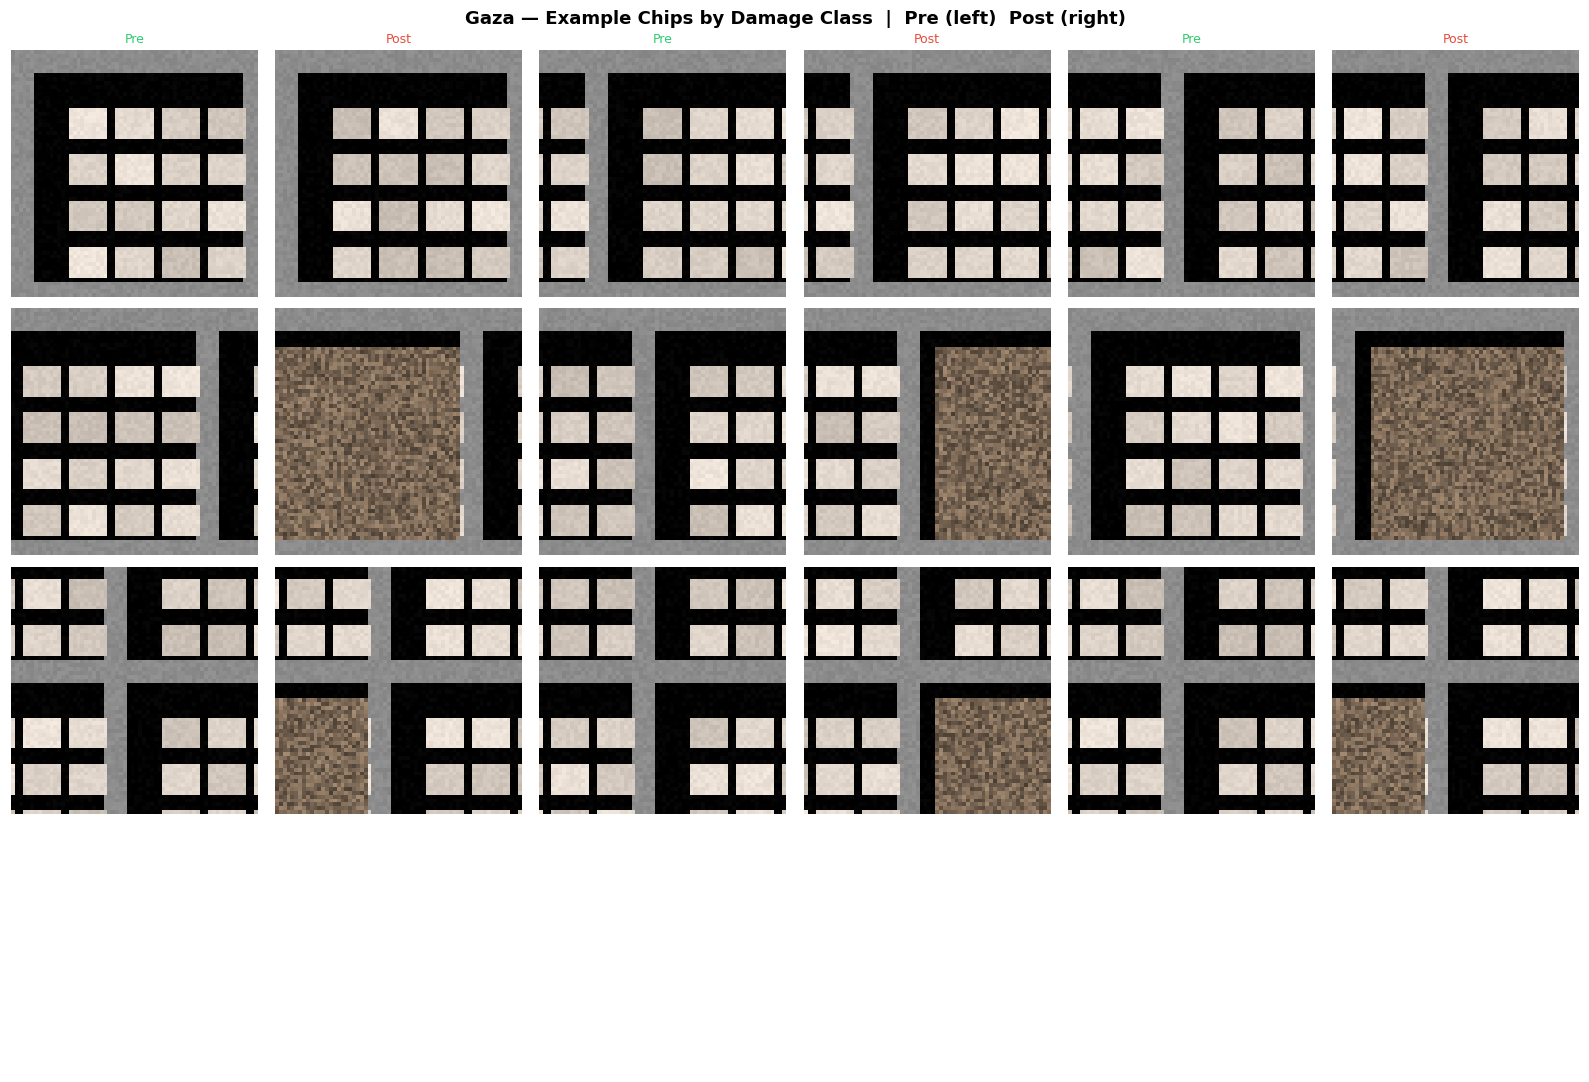

Saved: outputs\damage\05_chip_examples.png


In [4]:
import json
import numpy as np
from pathlib import Path

PREPARED_DIR = Path("data/prepared")
OUTPUT_DIR   = Path("outputs/damage")

DAMAGE_CLASSES = {0: "No Damage", 1: "Minor Damage", 2: "Major Damage", 3: "Destroyed"}
DAMAGE_COLORS  = ["#2ecc71", "#f39c12", "#e67e22", "#c0392b"]

import pandas as pd
df = pd.read_csv(OUTPUT_DIR/"damage_results.csv")

with open(PREPARED_DIR/"chips_meta.json") as f:
    meta = json.load(f)
pre_meta  = meta["pre"]
post_meta = meta["post"]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 6, figsize=(16, 11))
fig.suptitle("Gaza — Example Chips by Damage Class  |  Pre (left)  Post (right)",
             fontsize=13, fontweight="bold")

for row, (dmg_cls, dmg_label) in enumerate(DAMAGE_CLASSES.items()):
    matching = [i for i, d in enumerate(df["damage_class"]) if d == dmg_cls]

    if len(matching) == 0:
        for col in range(6):
            axes[row, col].set_facecolor("#222222")
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(dmg_label + " (no chips)", fontsize=9,
                                color=DAMAGE_COLORS[dmg_cls], rotation=90)
        continue

    samples = (matching * 3)[:3]

    for col_pair, chip_idx in enumerate(samples):
        pre_chip  = np.load(pre_meta[chip_idx]["path"]).transpose(1,2,0).clip(0,1)
        post_chip = np.load(post_meta[chip_idx]["path"]).transpose(1,2,0).clip(0,1)
        axes[row, col_pair*2].imshow(pre_chip)
        axes[row, col_pair*2].axis("off")
        axes[row, col_pair*2+1].imshow(post_chip)
        axes[row, col_pair*2+1].axis("off")

    axes[row, 0].set_ylabel(dmg_label, fontsize=10, fontweight="bold",
                            color=DAMAGE_COLORS[dmg_cls], rotation=90, labelpad=5)

for i in range(0, 6, 2):
    axes[0, i].set_title("Pre",  fontsize=9, color="#2ecc71")
    axes[0, i+1].set_title("Post", fontsize=9, color="#e74c3c")

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"05_chip_examples.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: " + str(OUTPUT_DIR/"05_chip_examples.png"))

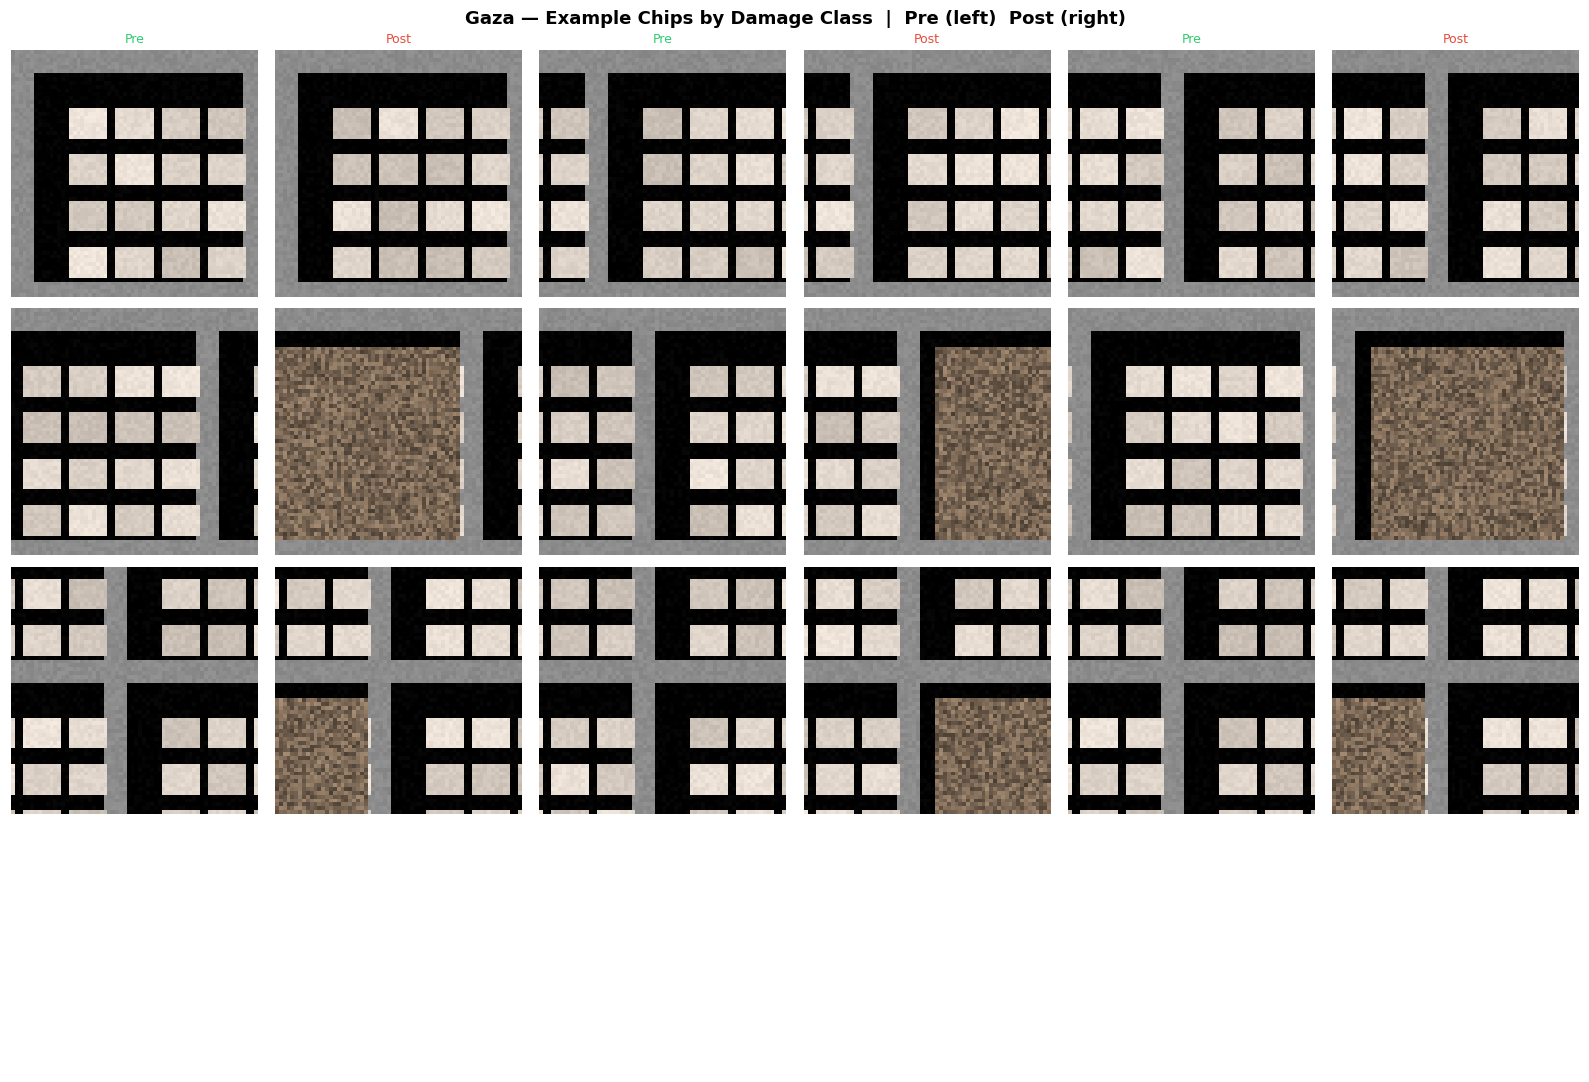

Saved: outputs\damage\05_chip_examples.png


In [6]:
import json
from pathlib import Path

with open(PREPARED_DIR/"chips_meta.json") as f:
    meta = json.load(f)
pre_meta  = meta["pre"]
post_meta = meta["post"]

fig, axes = plt.subplots(4, 6, figsize=(16, 11))
fig.suptitle("Gaza — Example Chips by Damage Class  |  Pre (left)  Post (right)",
             fontsize=13, fontweight="bold")

for row, (dmg_cls, dmg_label) in enumerate(DAMAGE_CLASSES.items()):
    matching = [i for i, d in enumerate(df["damage_class"]) if d == dmg_cls]

    if len(matching) == 0:
        for col in range(6):
            axes[row, col].set_facecolor("#222222")
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(dmg_label + " (no chips)", fontsize=9,
                                color=DAMAGE_COLORS[dmg_cls], rotation=90)
        continue

    samples = (matching * 3)[:3]

    for col_pair, chip_idx in enumerate(samples):
        pre_chip  = np.load(pre_meta[chip_idx]["path"]).transpose(1,2,0).clip(0,1)
        post_chip = np.load(post_meta[chip_idx]["path"]).transpose(1,2,0).clip(0,1)
        axes[row, col_pair*2].imshow(pre_chip)
        axes[row, col_pair*2].axis("off")
        axes[row, col_pair*2+1].imshow(post_chip)
        axes[row, col_pair*2+1].axis("off")

    axes[row, 0].set_ylabel(dmg_label, fontsize=10, fontweight="bold",
                            color=DAMAGE_COLORS[dmg_cls], rotation=90, labelpad=5)

for i in range(0, 6, 2):
    axes[0, i].set_title("Pre",  fontsize=9, color="#2ecc71")
    axes[0, i+1].set_title("Post", fontsize=9, color="#e74c3c")

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"05_chip_examples.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: " + str(OUTPUT_DIR/"05_chip_examples.png"))



## 📋 Figure 6 — Summary Card

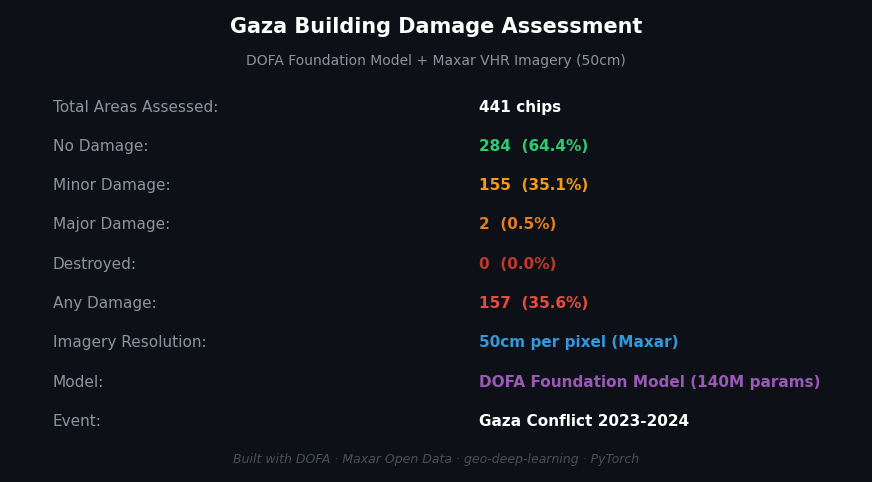

Saved: outputs\damage\06_summary_card.png
All visualisations complete!
Outputs saved to: C:\gaza-damage-assessment\outputs\damage


In [12]:
total      = len(df)
counts_all = df["damage_class"].value_counts().sort_index()
destroyed  = counts_all.get(3, 0)
major      = counts_all.get(2, 0)
minor      = counts_all.get(1, 0)
no_dmg     = counts_all.get(0, 0)
any_damage = destroyed + major + minor

fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off"); fig.patch.set_facecolor("#0d1117")

ax.text(0.5, 0.95, "Gaza Building Damage Assessment",
        transform=ax.transAxes, ha="center", fontsize=15,
        fontweight="bold", color="white")

ax.text(0.5, 0.88, "DOFA Foundation Model + Maxar VHR Imagery (50cm)",
        transform=ax.transAxes, ha="center", fontsize=10, color="#8b949e")

stats = [
    ("Total Areas Assessed",   f"{total:,} chips",                       "white"),
    ("No Damage",              f"{no_dmg:,}  ({no_dmg/total*100:.1f}%)", "#2ecc71"),
    ("Minor Damage",           f"{minor:,}  ({minor/total*100:.1f}%)",   "#f39c12"),
    ("Major Damage",           f"{major:,}  ({major/total*100:.1f}%)",   "#e67e22"),
    ("Destroyed",              f"{destroyed:,}  ({destroyed/total*100:.1f}%)", "#c0392b"),
    ("Any Damage",             f"{any_damage:,}  ({any_damage/total*100:.1f}%)", "#e74c3c"),
    ("Imagery Resolution",     "50cm per pixel (Maxar)",                 "#3498db"),
    ("Model",                  "DOFA Foundation Model (140M params)",    "#9b59b6"),
    ("Event",                  "Gaza Conflict 2023-2024",                "white"),
]
for i, (label, value, color) in enumerate(stats):
    y = 0.78 - i * 0.085
    ax.text(0.05, y, f"{label}:", transform=ax.transAxes, ha="left",
            fontsize=11, color="#8b949e")
    ax.text(0.55, y, value, transform=ax.transAxes, ha="left",
            fontsize=11, fontweight="bold", color=color)

ax.text(0.5, 0.02, "Built with DOFA · Maxar Open Data · geo-deep-learning · PyTorch",
        transform=ax.transAxes, ha="center", fontsize=9,
        color="#484f58", style="italic")
plt.savefig(OUTPUT_DIR/"06_summary_card.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Saved: " + str(OUTPUT_DIR/"06_summary_card.png"))
print("All visualisations complete!")
print("Outputs saved to: " + str(OUTPUT_DIR.resolve()))
